In [1]:
from ping import *
import sys
from utils import *

np.set_printoptions(threshold=sys.maxsize)

# Stationary Case, Single Reflector 

Goals:
* Verify number of cycles (low test frequency to see oscillations)
* Verify envelope shaping function
* Verify attenuated receive signal
    * Propagation
    * Reflection
* Verify combined total "Transducer History" signal (transmit-delay-receive)
* Verify constant transducer position (x,y,z vs time)

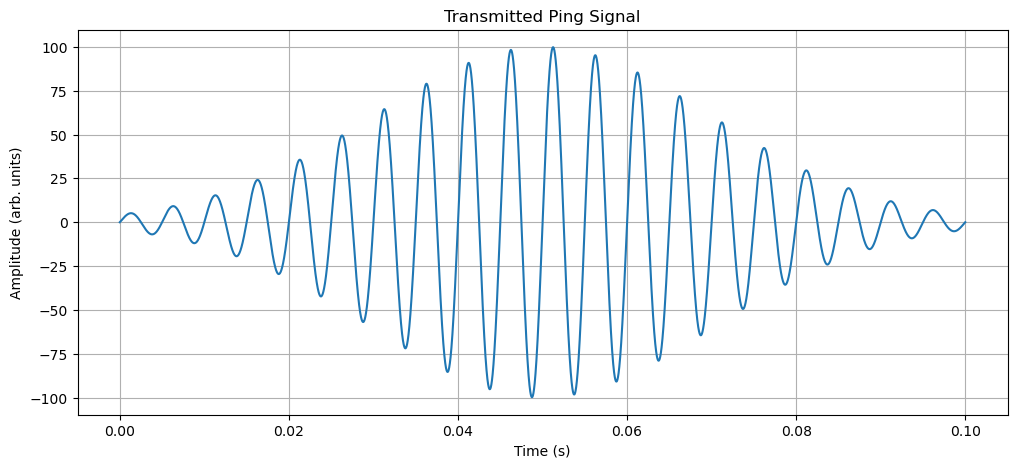

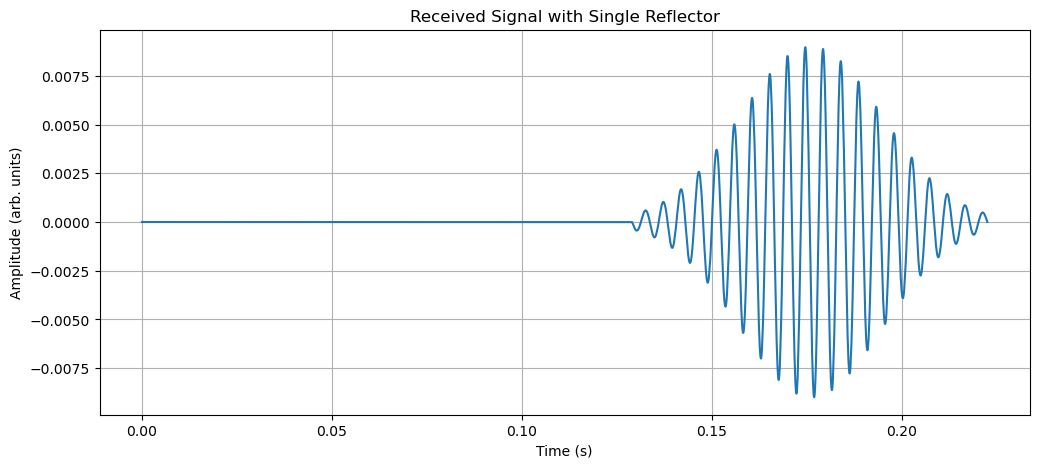

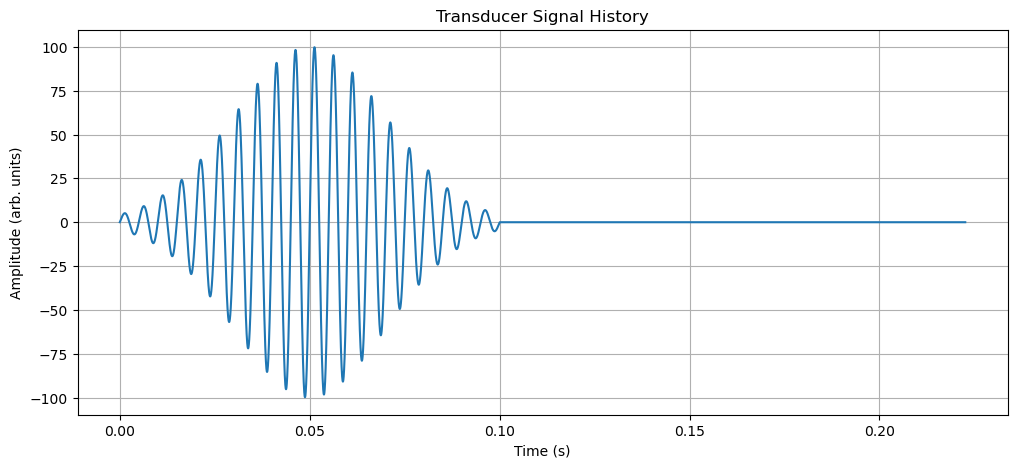

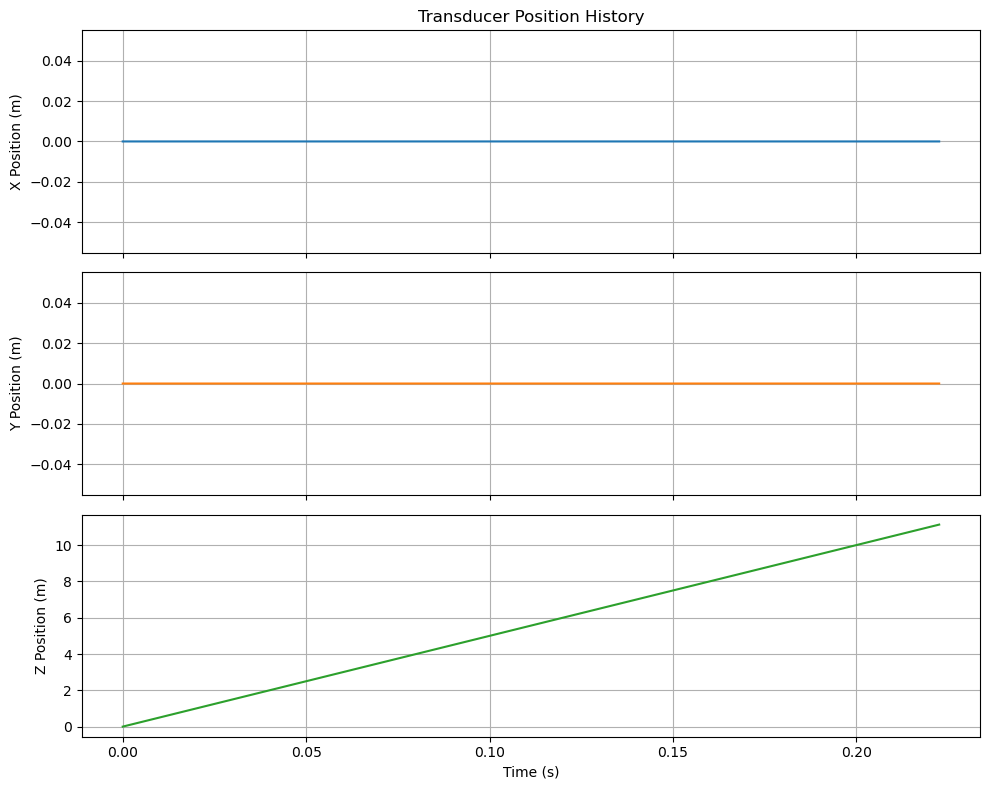

In [2]:
ping_object = Ping(
    frequency=2e2,
    n_cycles=20,
    duration=0.01,
    amplitude=100.0,
    phase=0,
    sample_rate=4e6,
    window_mode='gaussian'
)

transducer_object = Transducer(
    position=np.array([0.0, 0.0, 0.0]),
    velocity=np.array([0, 0, 50]),
    angle_deg=0.0,
    beam_width_deg=25.0
)

reflectors = [
    Reflector(
        position=np.array([0.0, 0.0, 150]),
        radius=50,
        reflectivity=0.8,
        phase_shift_deg=180.0
    ),
]

simulated_world = World(
    transducer=transducer_object,
    reflectors=reflectors,
)

simulated_world.run_simulation(ping_object)



plot_transmitted_signal(ping_object)
plot_received_signal(transducer_object, ping_object)
plot_transducer_history(transducer_object, ping_object)
plot_transducer_position(transducer_object, ping_object)

# Stationary Case, Multi-Reflector 

Goals:
* Use frequency values closer to what we expect in the real world ~200kHz
* Verify multiple echoes from one transmitted signal due to reflection off multiple reflectors
* Verify function to measure the frequency of the transmitted and received signal


# Constant Velocity Directly towards/away Single Reflector 

Goals:
* Verify a stretched/compressed doppler shifted receive signal depending on the direction of travel (compressed if moving towards, streched if moving away)
* Measure the frequency shift and compare to expected double doppler shift
* Compute a velocity estimate and compare to expectations

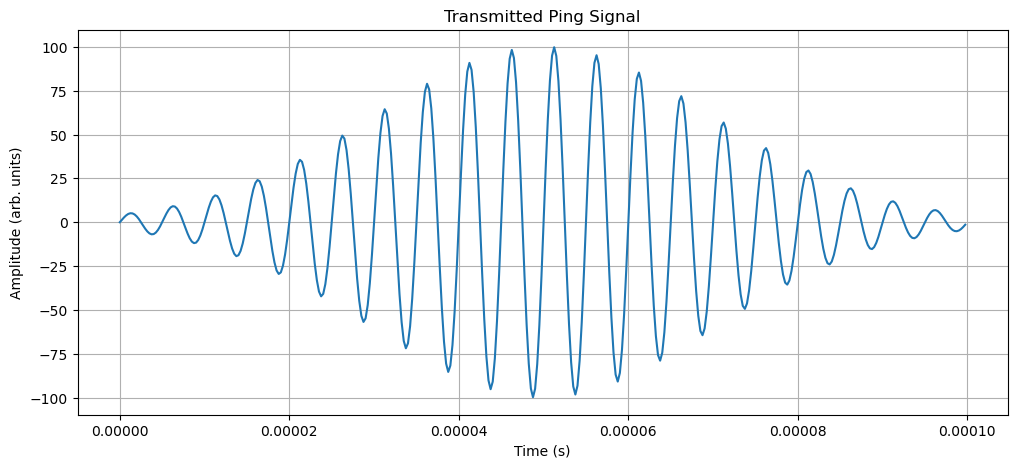

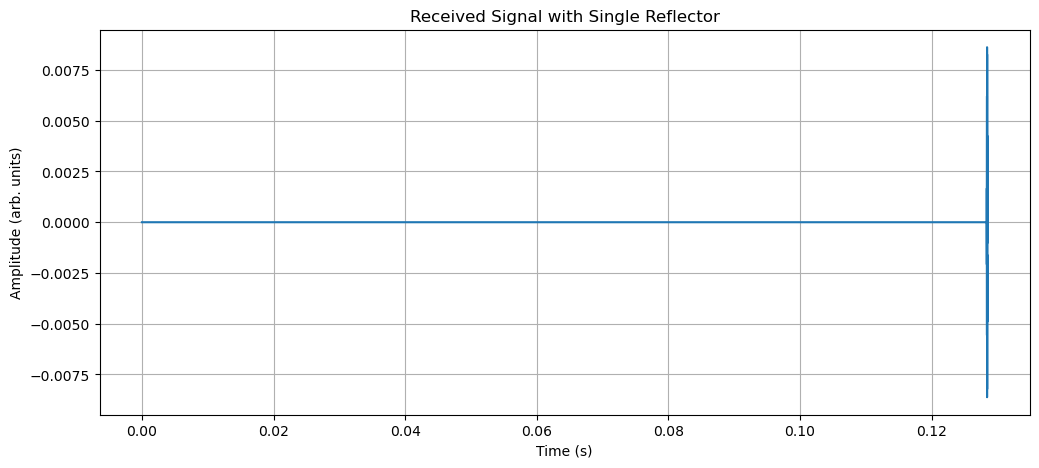

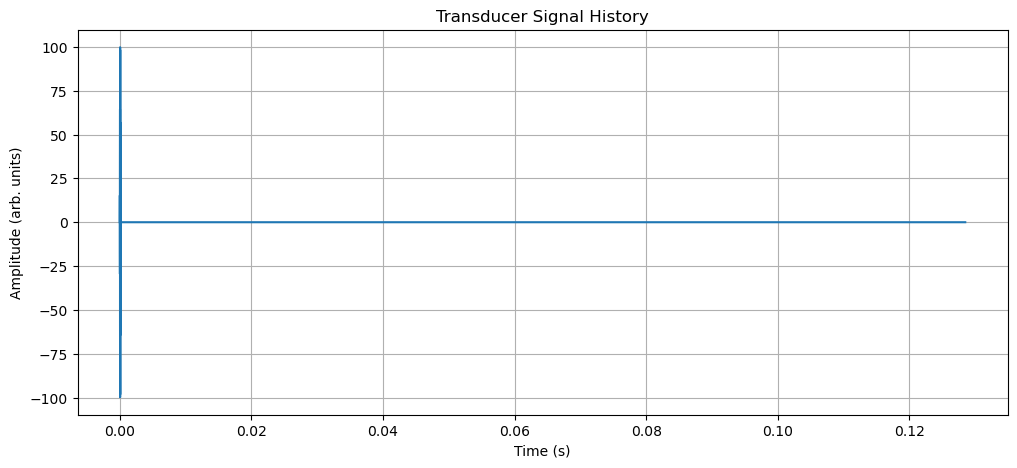

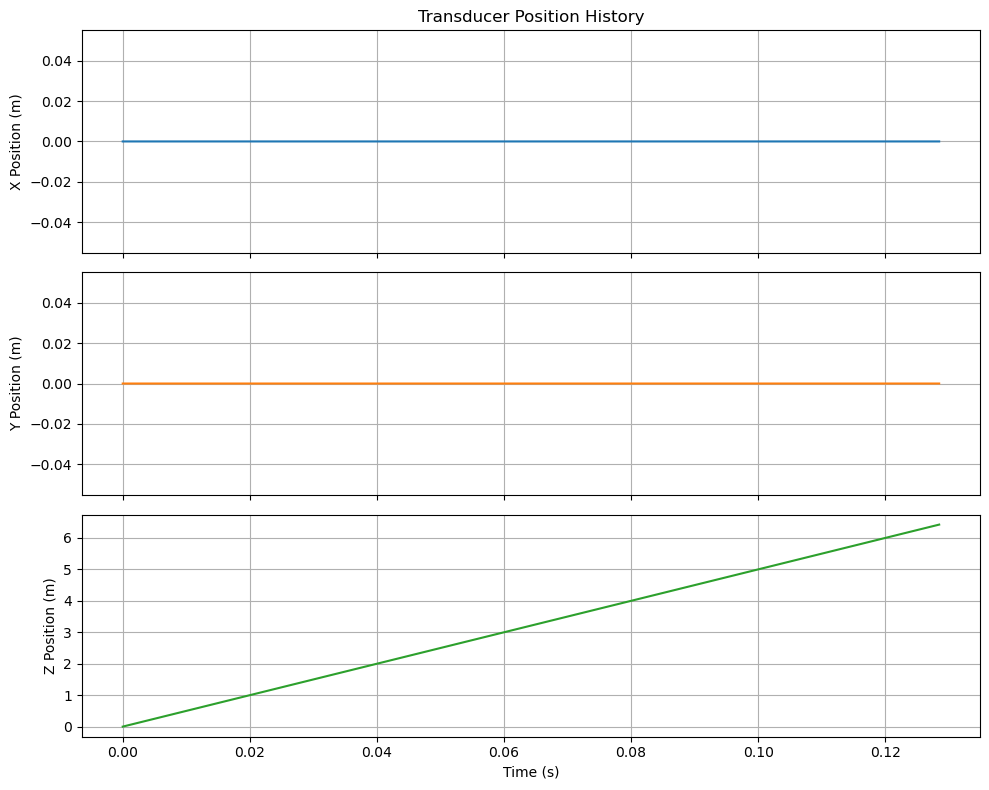

In [12]:
ping_object = Ping(
    frequency=200e3,
    n_cycles=20,
    amplitude=100.0,
    phase=0,
    sample_rate=4e6,
    window_mode='gaussian'
)

transducer_object = Transducer(
    position=np.array([0.0, 0.0, 0.0]),
    velocity=np.array([0, 0, 50]),
    angle_deg=0.0,
    beam_width_deg=25.0
)

reflectors = [
    Reflector(
        position=np.array([0.0, 0.0, 100]),
        radius=0.5,
        reflectivity=0.8,
        phase_shift_deg=180.0
    ),
]

simulated_world = World(
    transducer=transducer_object,
    reflectors=reflectors,
)

simulated_world.run_simulation(ping_object)

plot_transmitted_signal(ping_object)
plot_received_signal(transducer_object, ping_object)
plot_transducer_history(transducer_object, ping_object)
plot_transducer_position(transducer_object, ping_object)

In [4]:
peak_1, freqs_1, mag_1 = get_peak_frequency(ping_object.signal, ping_object.fs)
peak_2, freqs_2, mag_2 = get_peak_frequency(transducer_object.receive_signal, ping_object.fs)


separation_vec = reflectors[0].position - transducer_object.initial_position
dir = separation_vec / np.linalg.norm(separation_vec)
vel = np.dot(transducer_object.velocity, dir)
expected_doppler_shift = (2*ping_object.frequency*vel/World.c) + ping_object.frequency

print(f"Expected Doppler Shift Frequency: {expected_doppler_shift[0]:.2f} Hz")
print(f"Transmit Signal Peak Frequency: {peak_1:.2f} Hz")
print(f"Receive Signal Peak Frequency: {peak_2:.2f} Hz")

# plt.plot(freqs_1, mag_1, label='Transmit Signal Spectrum')
# plt.plot(freqs_2, mag_2, label='Receive Signal Spectrum')

Expected Doppler Shift Frequency: 213333.33 Hz
Transmit Signal Peak Frequency: 199985.90 Hz
Receive Signal Peak Frequency: 213776.97 Hz


# Constant Velocity at an Angle wrt Single Reflector 

Goals:
* Verify only the velcity component towards the reflector causes a frequency shift and compare to expected double doppler shift
* Compute a velocity estimate and compare to expectations

In [5]:
ping_object = Ping(
    frequency=200e3,
    n_cycles=60,
    amplitude=200.0,
    phase=0,
    sample_rate=4e6,
    window_mode='gaussian'
)

transducer_object = Transducer(
    position=np.array([0.0, 0.0, 0.0]),
    velocity=np.array([5,0,0]),
    angle_deg=0.0,
    beam_width_deg=25.0
)

reflectors = [
    Reflector(
        position=np.array([40, 0.0, -100]),
        radius=0.5,
        reflectivity=0.8,
        phase_shift_deg=180.0
    ),
]

simulated_world = World(
    transducer=transducer_object,
    reflectors=reflectors,
)

simulated_world.run_simulation(ping_object)

# plot_transmitted_signal(ping_object)
# plot_received_signal(transducer_object, ping_object)
# plot_transducer_history(transducer_object, ping_object)
# plot_transducer_position(transducer_object, ping_object)

In [6]:
peak_1, freqs_1, mag_1 = get_peak_frequency(ping_object.signal, ping_object.fs)
peak_2, freqs_2, mag_2 = get_peak_frequency(transducer_object.receive_signal, ping_object.fs)


separation_vec = reflectors[0].position - transducer_object.initial_position
dir = separation_vec / np.linalg.norm(separation_vec)
vel = np.dot(transducer_object.velocity, dir)
expected_doppler_shift = (2*ping_object.frequency*vel/World.c) + ping_object.frequency

print(f"Angle of Motion: {np.degrees(np.arccos(vel / np.linalg.norm(transducer_object.velocity))):.2f} degrees")
print(f"Expected Doppler Shift Frequency: {expected_doppler_shift[0]:.2f} Hz")
print(f"Transmit Signal Peak Frequency: {peak_1:.2f} Hz")
print(f"Receive Signal Peak Frequency: {peak_2:.2f} Hz \n")

freq_error = np.abs(peak_2 - expected_doppler_shift)
est_v, dest_v = compute_velocity(peak_2, peak_1, World.c, sigma_f_t=freq_error)
print(f"Estimated Velocity: {est_v:.2f} +/- {dest_v} m/s")
print(f"Actual Velocity: {vel:.2f} m/s")

# plt.plot(freqs_1, mag_1, label='Transmit Signal Spectrum')
# plt.plot(freqs_2, mag_2, label='Receive Signal Spectrum')

Angle of Motion: 68.20 degrees
Expected Doppler Shift Frequency: 200495.19 Hz
Transmit Signal Peak Frequency: 199998.43 Hz
Receive Signal Peak Frequency: 200481.08 Hz 

Estimated Velocity: 1.81 +/- [0.05278175] m/s
Actual Velocity: 1.86 m/s


# Constant Velocity, Multiple Reflectors

Goals:
* Verify that only the reflectors in the transducer's beam angle are able to reflect the transmitted signal

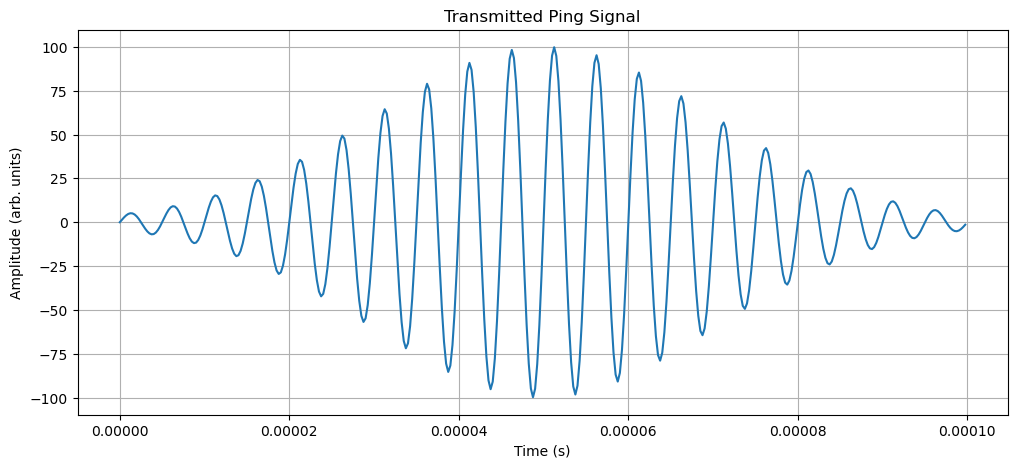

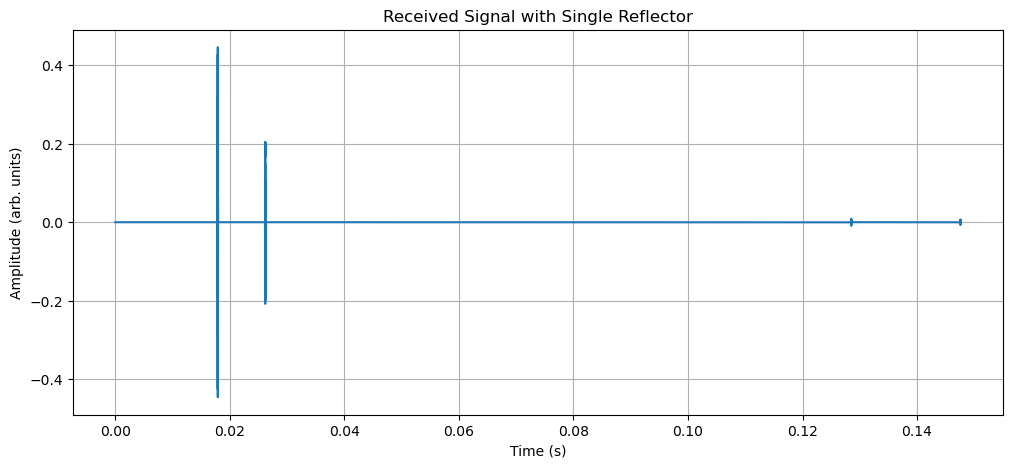

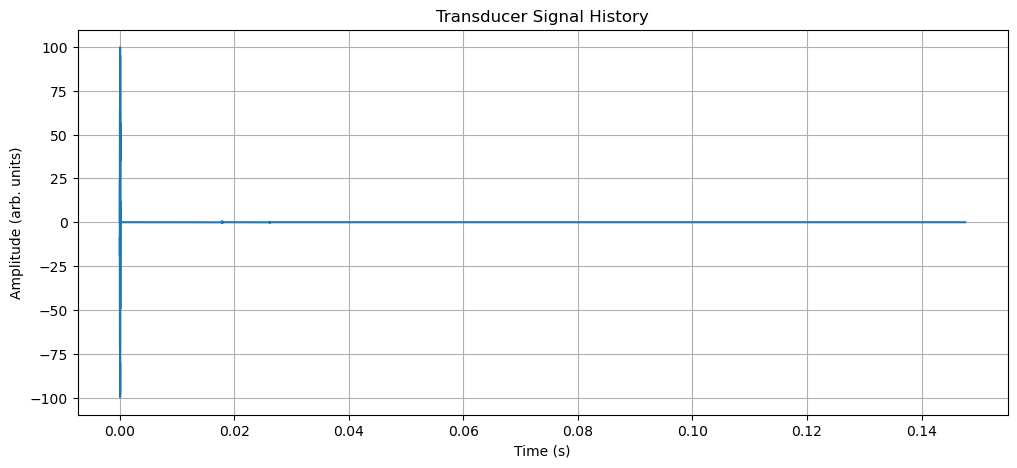

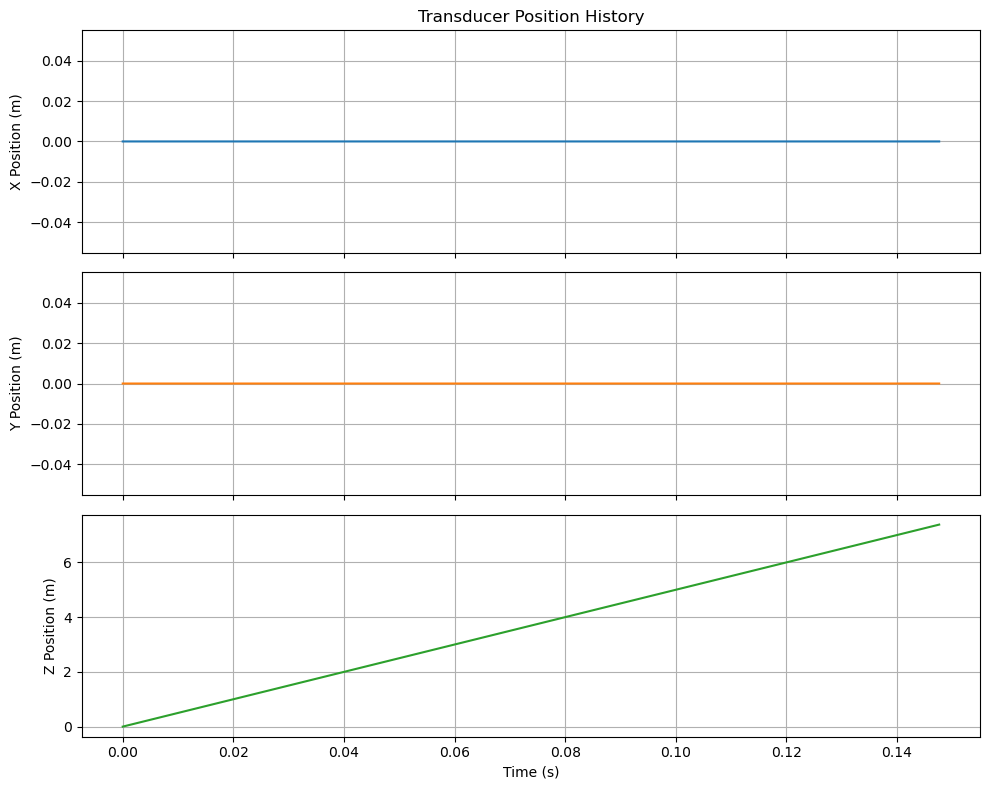

In [14]:
ping_object = Ping(
    frequency=200e3,
    n_cycles=20,
    amplitude=100.0,
    phase=0,
    sample_rate=4e6,
    window_mode='gaussian'
)

transducer_object = Transducer(
    position=np.array([0.0, 0.0, 0.0]),
    velocity=np.array([0, 0, 50]),
    angle_deg=0.0,
    beam_width_deg=25.0
)

reflectors = [
    Reflector(
        position=np.array([40, 0.0, -100]),
        radius=0.5,
        reflectivity=0.8,
        phase_shift_deg=180.0
    ),
    Reflector(
        position=np.array([0.0, 3.0, 100]),
        radius=0.5,
        reflectivity=0.8,
        phase_shift_deg=180.0
    ),
    Reflector(
        position=np.array([-5, 0, 15]),
        radius=2,
        reflectivity=0.8,
        phase_shift_deg=180.0
    ),
    Reflector(
        position=np.array([5, 5, 20]),
        radius=1,
        reflectivity=0.8,
        phase_shift_deg=180.0
    ),
]

simulated_world = World(
    transducer=transducer_object,
    reflectors=reflectors,
)

simulated_world.run_simulation(ping_object)

plot_transmitted_signal(ping_object)
plot_received_signal(transducer_object, ping_object)
plot_transducer_history(transducer_object, ping_object)
plot_transducer_position(transducer_object, ping_object)